In [42]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

FINAL_RESULTS = Path("final_results")
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # 비교는 항상 4개 이하라 여기서 한 번만 선언


def load_scores(run_dir):
    """final_results/<run_dir>/<AGENT_seed_timestamp>/episodes.csv 에서 score 열만 뽑아온다."""
    csv_path = sorted((FINAL_RESULTS / run_dir).glob("*/episodes.csv"))[0]
    with open(csv_path, newline="", encoding="utf-8") as handle:
        return np.array([float(row["score"]) for row in csv.DictReader(handle)])


runs = {
    "DDQN MLP (vecenv)": "ddqn_vec_mlp",
    "DDQN attention (vecenv)": "ddqn_vec_attention",
    "DDQN CNN (imgenv)": "ddqn_img_cnn",
    "PQN attention (vecenv)": "pqn_vec_attention",
    "PQN attention (vecenv) + anneal": "pqn_vec_attention_anneal",
    "DDQN CNN (imgenv) + DA + long": "ddqn_img_cnn_aug_5000",
    "PQN CNN (imgenv) + DA + long": "pqn_img_cnn_aug_20m",
    "DDQN MLP (vecenv) + long": "ddqn_vec_mlp_10000",
    "PQN attention (vecenv) + short": "pqn_vec_attention_1m_epoch2",
    "PQN attention (vecenv) + short + DA": "pqn_vec_attention_1m_epoch2_aug",
    "PQN attention (vecenv) + short + epoch 4": "pqn_vec_attention_1m_epoch4",
    "PQN attention (vecenv) + short + DA + epoch 4": "pqn_vec_attention_1m_epoch4_aug",
}
scores = {label: load_scores(run_dir) for label, run_dir in runs.items()}

for label, values in scores.items():
    print(
        f"{label:50s} episodes={len(values):5d} "
        f"max={values.max():5.0f} "
        f"last100_mean={values[-100:].mean():6.2f}"
    )

DDQN MLP (vecenv)                                  episodes= 3000 max=   47 last100_mean= 15.24
DDQN attention (vecenv)                            episodes= 3000 max=  100 last100_mean= 37.86
DDQN CNN (imgenv)                                  episodes= 3000 max=   37 last100_mean=  9.21
PQN attention (vecenv)                             episodes= 8859 max=  148 last100_mean= 62.10
PQN attention (vecenv) + anneal                    episodes= 7612 max=  180 last100_mean= 99.87
DDQN CNN (imgenv) + DA + long                      episodes= 5000 max=   42 last100_mean= 11.24
PQN CNN (imgenv) + DA + long                       episodes=76518 max=   65 last100_mean= 25.90
DDQN MLP (vecenv) + long                           episodes=10000 max=   60 last100_mean= 21.37
PQN attention (vecenv) + short                     episodes= 2675 max=   94 last100_mean= 54.89
PQN attention (vecenv) + short + DA                episodes= 2357 max=  113 last100_mean= 63.03
PQN attention (vecenv) + short + epoch 4

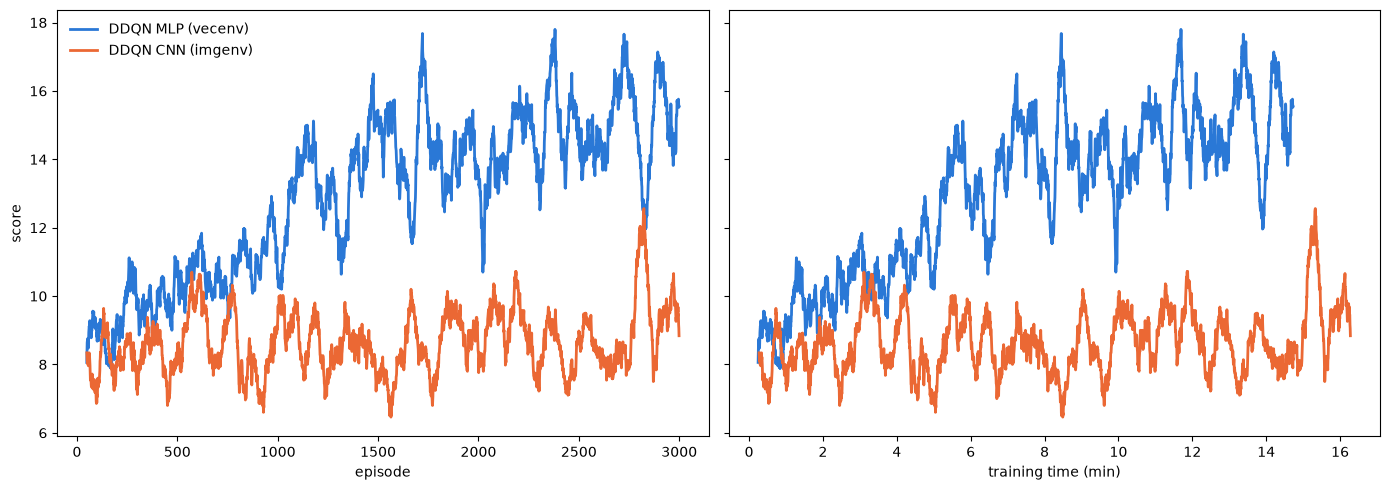

In [43]:
# score 학습 곡선 비교 (이동평균), x축은 episode / 학습 시간 두 가지로 그린다.
# DDQN comparison
# vecenv vs imgenv

import json

WINDOW = 50


def moving_average(values, window):
    return np.convolve(values, np.ones(window) / window, mode="valid")


def load_elapsed_seconds(run_dir):
    json_path = sorted((FINAL_RESULTS / run_dir).glob("*/results.json"))[0]
    return json.loads(json_path.read_text(encoding="utf-8"))["elapsed_seconds"]

labels = ["DDQN MLP (vecenv)", "DDQN CNN (imgenv)"]
figure, (episode_axis, time_axis) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)  # y축 공유
for (label, color) in zip(labels, COLORS):
    values = scores[label]
    smooth = moving_average(values, WINDOW)
    episode = np.arange(len(smooth)) + WINDOW - 1
    episode_axis.plot(episode, smooth, color=color, linewidth=2, label=f"{label}")

    # 흐른 시간과 맞추는게 아니고 그냥 늘림
    elapsed_minutes = load_elapsed_seconds(runs[label]) / 60
    time_axis.plot(
        (episode + 1) / len(values) * elapsed_minutes,
        smooth,
        color=color,
        linewidth=2,
        label=f"{label}",
    )

episode_axis.set_xlabel("episode")
episode_axis.set_ylabel("score")
time_axis.set_xlabel("training time (min)")
episode_axis.legend(frameon=False)  # legend box 없애기 
plt.tight_layout()
plt.show()

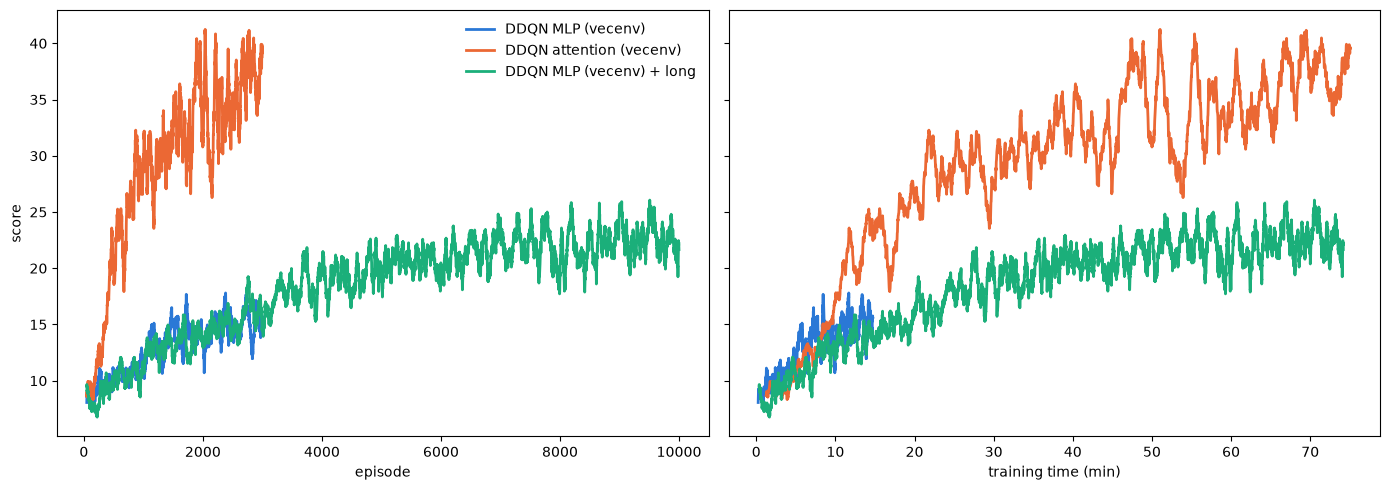

In [44]:
# 모델 구조 comparison
# mlp vs attention

labels = ["DDQN MLP (vecenv)", "DDQN attention (vecenv)", "DDQN MLP (vecenv) + long"]

figure, (episode_axis, time_axis) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for label, color in zip(labels, COLORS):
    values = scores[label]
    smooth = moving_average(values, WINDOW)
    episode = np.arange(len(smooth)) + WINDOW - 1
    episode_axis.plot(episode, smooth, color=color, linewidth=2, label=f"{label}")

    elapsed_minutes = load_elapsed_seconds(runs[label]) / 60
    time_axis.plot(
        (episode + 1) / len(values) * elapsed_minutes,
        smooth,
        color=color,
        linewidth=2,
        label=f"{label}",
    )

episode_axis.set_xlabel("episode")
episode_axis.set_ylabel("score")
time_axis.set_xlabel("training time (min)")
episode_axis.legend(frameon=False)
plt.tight_layout()
plt.show()

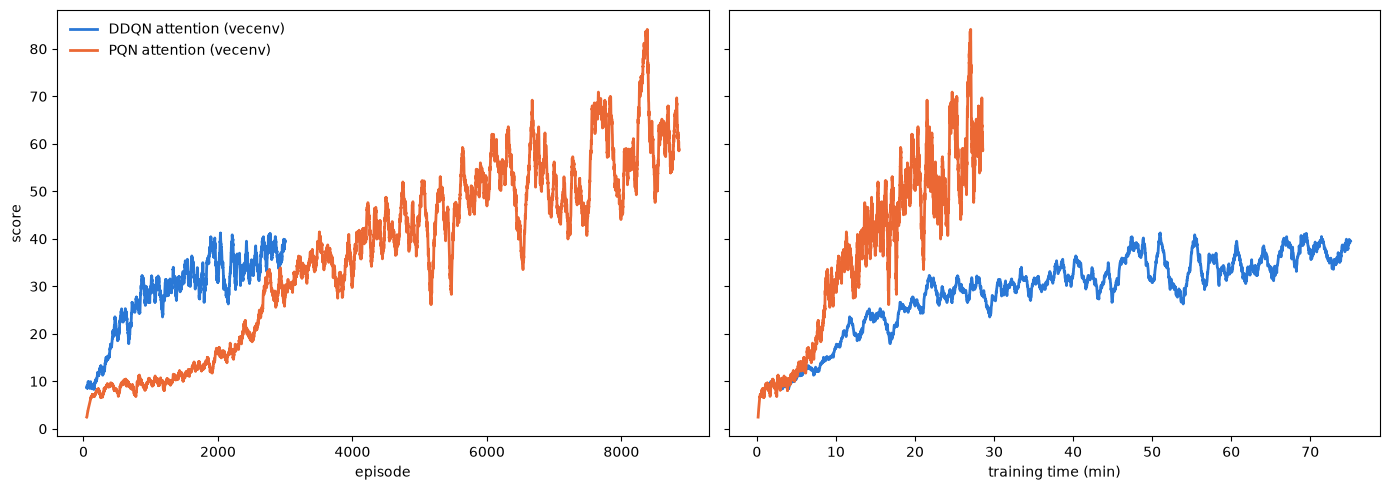

In [45]:
# 알고리즘 별 comparison
# ddqn vs pqn

# 알고리즘만 다른 쌍이라 둘 다 attention vecenv 로 비교한다.
labels = ["DDQN attention (vecenv)", "PQN attention (vecenv)"]

figure, (episode_axis, time_axis) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for label, color in zip(labels, COLORS):
    values = scores[label]
    smooth = moving_average(values, WINDOW)
    episode = np.arange(len(smooth)) + WINDOW - 1
    episode_axis.plot(episode, smooth, color=color, linewidth=2, label=f"{label}")

    elapsed_minutes = load_elapsed_seconds(runs[label]) / 60
    time_axis.plot(
        (episode + 1) / len(values) * elapsed_minutes,
        smooth,
        color=color,
        linewidth=2,
        label=f"{label}",
    )

episode_axis.set_xlabel("episode")
episode_axis.set_ylabel("score")
time_axis.set_xlabel("training time (min)")
episode_axis.legend(frameon=False)
plt.tight_layout()
plt.show()

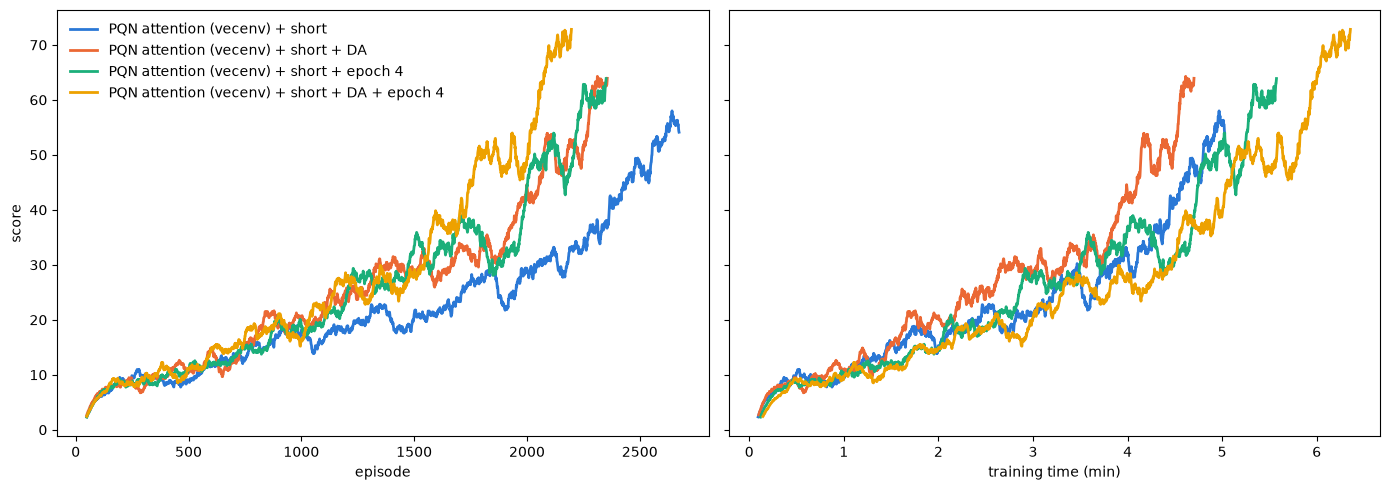

In [46]:
# 추가 기법들 결정
# pqn attention vecenv + (DA) + (n_epochs=2,4)

labels = [
    "PQN attention (vecenv) + short",
    "PQN attention (vecenv) + short + DA",
    "PQN attention (vecenv) + short + epoch 4",
    "PQN attention (vecenv) + short + DA + epoch 4",
]

figure, (episode_axis, time_axis) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for label, color in zip(labels, COLORS):
    values = scores[label]
    smooth = moving_average(values, WINDOW)
    episode = np.arange(len(smooth)) + WINDOW - 1
    episode_axis.plot(episode, smooth, color=color, linewidth=2, label=f"{label}")

    elapsed_minutes = load_elapsed_seconds(runs[label]) / 60
    time_axis.plot(
        (episode + 1) / len(values) * elapsed_minutes,
        smooth,
        color=color,
        linewidth=2,
        label=f"{label}",
    )

episode_axis.set_xlabel("episode")
episode_axis.set_ylabel("score")
time_axis.set_xlabel("training time (min)")
episode_axis.legend(frameon=False)
plt.tight_layout()
plt.show()

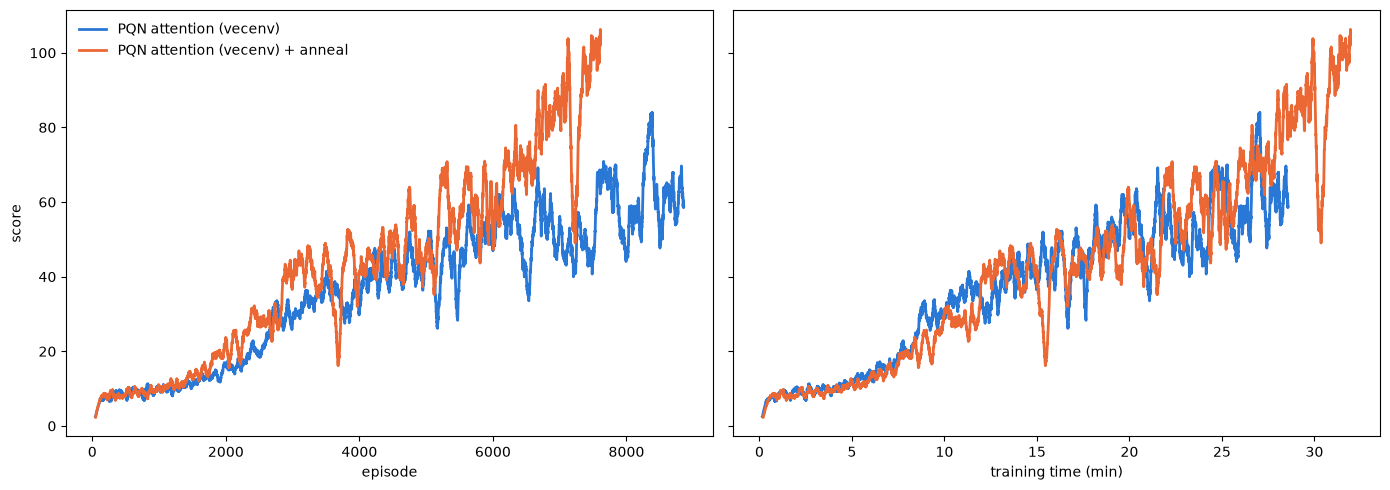

In [ ]:
# 추가 기법들 결정
# pqn attention vecenv + (anneal)

labels = [
    "PQN attention (vecenv)",
    "PQN attention (vecenv) + anneal",
]

figure, (episode_axis, time_axis) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for label, color in zip(labels, COLORS):
    values = scores[label]
    smooth = moving_average(values, WINDOW)
    episode = np.arange(len(smooth)) + WINDOW - 1
    episode_axis.plot(episode, smooth, color=color, linewidth=2, label=f"{label}")

    elapsed_minutes = load_elapsed_seconds(runs[label]) / 60
    time_axis.plot(
        (episode + 1) / len(values) * elapsed_minutes,
        smooth,
        color=color,
        linewidth=2,
        label=f"{label}",
    )

episode_axis.set_xlabel("episode")
episode_axis.set_ylabel("score")
time_axis.set_xlabel("training time (min)")
episode_axis.legend(frameon=False)
plt.tight_layout()
plt.show()

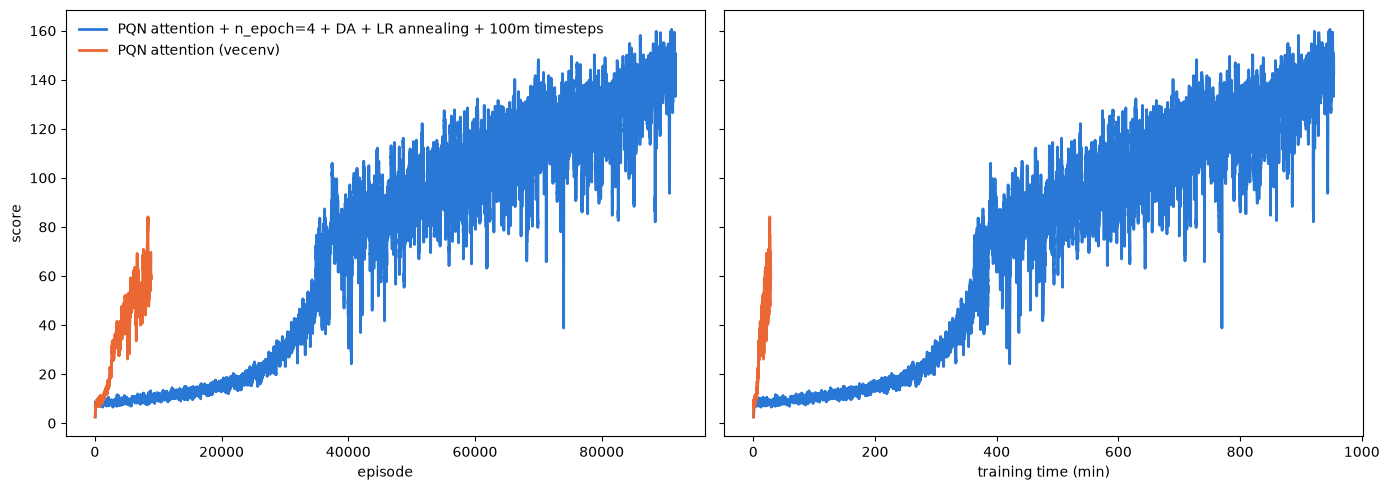

PQN attention + n_epoch=4 + DA + LR annealing + 100m timesteps         episodes= 91660 minutes=  953.9 max=  180 last100_mean=144.23
PQN attention (vecenv)                                                 episodes=  8859 minutes=   28.6 max=  148 last100_mean= 62.10


In [ ]:
# PQN_seed1_0805_185626_best 를 load
# pqn baseline 과 비교

BEST_DIR = FINAL_RESULTS / "PQN_seed1_0805_185626_best"
with open(BEST_DIR / "episodes.csv", newline="", encoding="utf-8") as handle:
    best_values = np.array([float(row["score"]) for row in csv.DictReader(handle)])
best_minutes = json.loads((BEST_DIR / "results.json").read_text(encoding="utf-8"))["elapsed_seconds"] / 60

baseline_label = "PQN attention (vecenv)"
best_label = "PQN attention + n_epoch=4 + DA + LR annealing + 100m timesteps"
pair_values = {best_label: best_values, baseline_label: scores[baseline_label]}
pair_minutes = {best_label: best_minutes, baseline_label: load_elapsed_seconds(runs[baseline_label]) / 60}



figure, (episode_axis, time_axis) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for (label, values), color in zip(pair_values.items(), COLORS):
    smooth = moving_average(values, WINDOW)
    episode = np.arange(len(smooth)) + WINDOW - 1
    episode_axis.plot(episode, smooth, color=color, linewidth=2, label=f"{label}")

    time_axis.plot(
        (episode + 1) / len(values) * pair_minutes[label],
        smooth,
        color=color,
        linewidth=2,
        label=f"{label}",
    )

episode_axis.set_xlabel("episode")
episode_axis.set_ylabel("score")
time_axis.set_xlabel("training time (min)")
episode_axis.legend(frameon=False)
plt.tight_layout()
plt.show()

for label, values in pair_values.items():
    print(
        f"{label:70s} episodes={len(values):6d} "
        f"minutes={pair_minutes[label]:7.1f} "
        f"max={values.max():5.0f} "
        f"last100_mean={values[-100:].mean():6.2f}"
    )


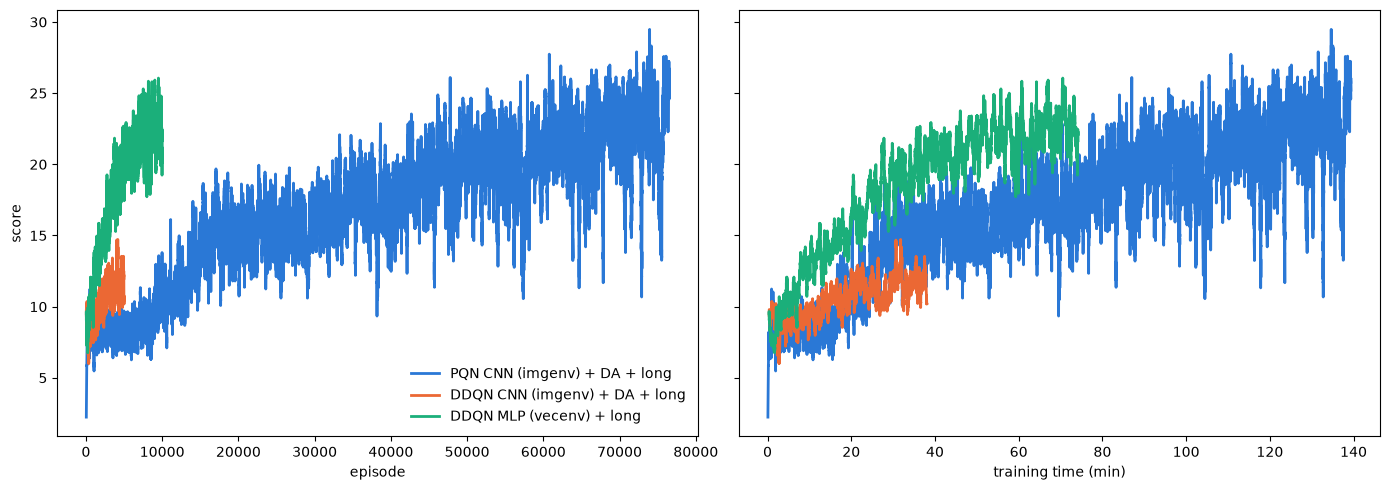

In [ ]:
# imgenv는 아예 학습이 불가능한가?
# ddqn cnn imgenv  + (DA + long training)
# pqn cnn imgenv  + (DA + long training)

labels = ["PQN CNN (imgenv) + DA + long", "DDQN CNN (imgenv) + DA + long"]

figure, (episode_axis, time_axis) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for label, color in zip(labels, COLORS):
    values = scores[label]
    smooth = moving_average(values, WINDOW)
    episode = np.arange(len(smooth)) + WINDOW - 1
    episode_axis.plot(episode, smooth, color=color, linewidth=2, label=f"{label}")

    elapsed_minutes = load_elapsed_seconds(runs[label]) / 60
    time_axis.plot(
        (episode + 1) / len(values) * elapsed_minutes,
        smooth,
        color=color,
        linewidth=2,
        label=f"{label}",
    )

episode_axis.set_xlabel("episode")
episode_axis.set_ylabel("score")
time_axis.set_xlabel("training time (min)")
episode_axis.legend(frameon=False)
plt.tight_layout()
plt.show()